# 02 – Exploratory Data Analysis

## Project Overview

In this notebook, I explore the cleaned LinkedIn job postings dataset to better understand the relationships between job characteristics and salary.

The objectives of this analysis are to:

- Understand the distribution of salaries
- Explore relationships between salary and categorical features
- Identify trends across job titles, locations, and experience levels
- Generate insights that will guide feature engineering and model development

The findings from this notebook will inform the machine learning models built later in the project.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [3]:
# Load clean dataset
project_root = Path.cwd().parent

processed_dir = project_root / "data" / "processed"

df = pd.read_csv(processed_dir / "clean_jobs.csv")

df.head()

,title,location,formatted_work_type,formatted_experience_level,company_name,views,normalized_salary
0,Marketing Coordinator,"Princeton, NJ",Full-time,Unknown,Corcoran Sawyer Smith,20.0,38480.0
1,Mental Health Therapist/Counselor,"Fort Collins, CO",Full-time,Unknown,Unknown,1.0,83200.0
2,Assitant Restaurant Manager,"Cincinnati, OH",Full-time,Unknown,The National Exemplar,8.0,55000.0
3,Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",Full-time,Unknown,"Abrams Fensterman, LLP",16.0,157500.0
4,Service Technician,"Burlington, IA",Full-time,Unknown,Unknown,3.0,70000.0


## Dataset Overview

Before creating visualizations, I first check the size and structure of the cleaned dataset.

In [4]:
df.shape

(36073, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36073 entries, 0 to 36072
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   title                       36073 non-null  str    
 1   location                    36073 non-null  str    
 2   formatted_work_type         36073 non-null  str    
 3   formatted_experience_level  36073 non-null  str    
 4   company_name                36073 non-null  str    
 5   views                       36073 non-null  float64
 6   normalized_salary           36073 non-null  float64
dtypes: float64(2), str(5)
memory usage: 1.9 MB


In [6]:
df.describe()

,views,normalized_salary
count,36073.000000,3.607300e+04
mean,19.456907,2.053270e+05
std,122.722634,5.097627e+06
min,1.000000,0.000000e+00
25%,3.000000,5.200000e+04
50%,5.000000,8.150000e+04
75%,10.000000,1.250000e+05
max,9975.000000,5.356000e+08


## Salary Distribution

I begin by examining the distribution of salaries to understand the range, spread, and potential outliers in the dataset.

Understanding the target variable is an important first step before developing machine learning models.

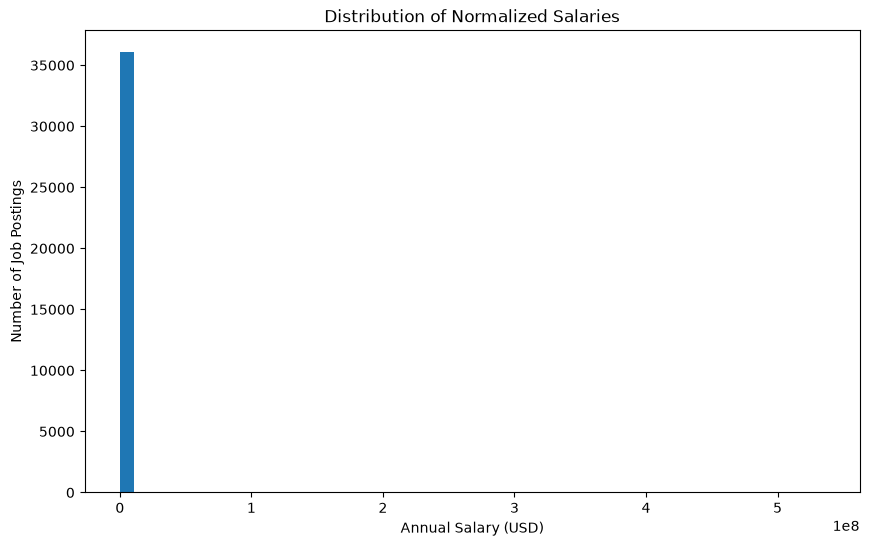

In [7]:
plt.figure(figsize=(10,6))

plt.hist(df["normalized_salary"], bins=50)

plt.title("Distribution of Normalized Salaries")

plt.xlabel("Annual Salary (USD)")

plt.ylabel("Number of Job Postings")

plt.show()

In [8]:
#Top 10 salaries
df["normalized_salary"].nlargest(10)

2736     535600000.0
29129    362408800.0
3956     286000000.0
26306    286000000.0
17880    260000000.0
30296    230423440.0
21315    228800000.0
21537    187200000.0
4863     156000000.0
25832    135200000.0
Name: normalized_salary, dtype: float64

## Investigating Extreme Salary Values

The summary statistics revealed several unusually large salary values. Before deciding how to handle these observations, I'll inspect the corresponding job postings to determine whether they appear to be legitimate or data anomalies.

In [9]:
df.nlargest(
    10,
    "normalized_salary"
)

,title,location,formatted_work_type,formatted_experience_level,company_name,views,normalized_salary
2736,Intellectual Property Associate (246215),"Dallas, TX",Full-time,Entry level,Eastridge Workforce Solutions,4.0,535600000.0
29129,"Case Manager RN, Pedi Rheumatology","Roseville, CA",Full-time,Mid-Senior level,Kaiser Permanente,4.0,362408800.0
3956,Cloud Domain Architect,"Houston, TX",Full-time,Mid-Senior level,Applicantz,2.0,286000000.0
26306,Cloud Domain Architect,"Houston, TX",Full-time,Mid-Senior level,Applicantz,42.0,286000000.0
17880,Billing Supervisor (246521),"Westwood, CA",Full-time,Mid-Senior level,Eastridge Workforce Solutions,4.0,260000000.0
30296,Manager - Clinical Applications Support - Anci...,"Lakeland, FL",Full-time,Unknown,Lakeland Regional Health-Florida,2.0,230423440.0
21315,Sharepoint Developer,"Springfield, Illinois Metropolitan Area",Full-time,Unknown,"DigiDoc, Inc. dba Public Sector Solutions Group",2.0,228800000.0
21537,Trial Paralegal - Hybrid in OC or LA!,"Los Angeles County, CA",Full-time,Mid-Senior level,Adams & Martin Group,2.0,187200000.0
4863,DCS Technician,"Charleston, SC",Full-time,Entry level,Jobot,5.0,156000000.0
25832,Full Time Field Service Technician – Anaheim/P...,"Anaheim, CA",Full-time,Entry level,The Hillman Group,7.0,135200000.0
